In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.utils_figures import Read_midi, make_pianoroll

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rc('pdf', fonttype=42)

serif_fontname = 'Noto Serif'

## Figure Pianoroll

1 cello | 2 contrabass | 3 timpani | 4 strings | 5 trumpet | 6 horn | 7 oboe | 8 bassoon | 9 clarinet | 10 flute | 1 cello | 2 contrabass | 3 timpani | 4 strings | 5 trumpet | 6 horn | 7 oboe | 8 bassoon | 9 clarinet | 10 flute | 1 piano | 1 piano | 2 trumpet | 3 tuba | 4 alto-saxophone | 5 clarinet | 6 flute | 1 cello | 2 contrabass | 3 timpani | 4 strings | 5 trumpet | 6 horn | 7 oboe | 8 bassoon | 9 clarinet | 10 flute | 

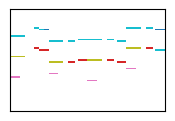

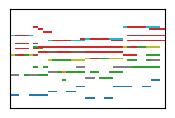

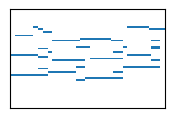

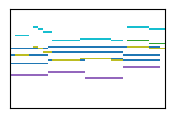

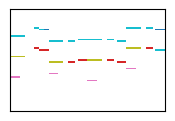

In [3]:
midi_data = Read_midi("midi_examples/orchestra_winds_less.mid", 4).read_file()
pr_orch_less = make_pianoroll(midi_data)
plt.savefig('figures/pianoroll_orchestra_winds_less.pdf', bbox_inches='tight')

midi_data = Read_midi("midi_examples/orchestra_trumpet_more.mid", 4).read_file()
pr_orch_more = make_pianoroll(midi_data)
plt.savefig('figures/pianoroll_orchestra_trumpet_more.pdf', bbox_inches='tight')

midi_data = Read_midi("midi_examples/piano2.mid", 4).read_file()
pr_piano = make_pianoroll(midi_data)
plt.savefig('figures/pianoroll_piano.pdf', bbox_inches='tight')

midi_data = Read_midi("midi_examples/orig.mid", 4).read_file()
pr_orig = make_pianoroll(midi_data)
plt.savefig('figures/pianoroll_orig.pdf', bbox_inches='tight')

midi_data = Read_midi("midi_examples/orchestra_winds_less.mid", 4).read_file()
pr_orch_less = make_pianoroll(midi_data)

In [4]:
def make_df_instr_onsets(pr):
  list_instr_onsets = list()
  for pitch in range(pr.shape[0]):
      new_line = []
      last_instr = -1
      for pos in range(pr.shape[1]):
          instr = pr[pitch, pos]
          if not(np.isnan(instr)):
              list_instr_onsets.append({
                  'instr': int(instr),
                  'pitch': pitch,
                  'pos': pos
              })
  df_instr_onsets = pd.DataFrame(list_instr_onsets)

  df_instr_onsets_grouped = df_instr_onsets\
    .groupby((
        (df_instr_onsets.pos != df_instr_onsets.pos.shift() + 1) | (df_instr_onsets.instr != df_instr_onsets.instr.shift())
      ).cumsum()).agg(
      instr = ('instr', 'first'), 
      pitch = ('pitch', 'first'),
      min_pos = ('pos', 'min'), 
      max_pos = ('pos', 'max'),
    ).reset_index(drop=True)
      
  df_instr_onsets_grouped['max_pos'] = df_instr_onsets_grouped.max_pos + 1
  
  return df_instr_onsets_grouped

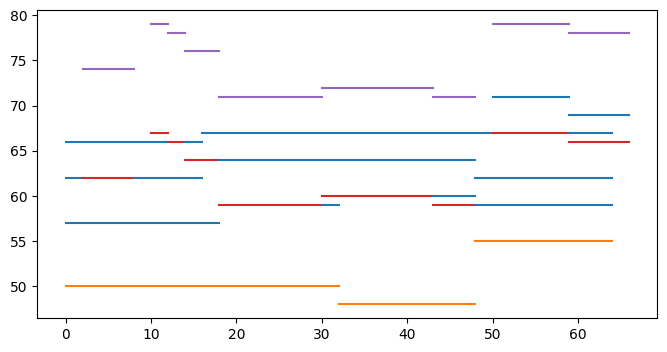

In [5]:
pr = pr_orig # pr_orig

cmap = mpl.colormaps.get_cmap("tab10")

df_instr_onsets = make_df_instr_onsets(pr)
plt.figure(figsize=(8, 4))
for ii, row in df_instr_onsets.iterrows():
    c = cmap(int(row['instr']) -2)
    plt.plot([row.min_pos, row.max_pos], [row.pitch, row.pitch], c=c)
plt.show()

In [6]:
df_instr_onsets['plotcolor'] = df_instr_onsets.instr.apply(lambda x: f"tab-{x}")
df_instr_onsets.to_csv('pianoroll_orig.csv', index=False)

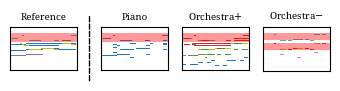

In [7]:
import matplotlib.patches as patches
fig = plt.figure(figsize=(4, 4))

rectprops = dict(linewidth=0, edgecolor='r', facecolor='red', alpha=0.4)


ax_orig = fig.add_subplot(1,4,1)
ax_piano = fig.add_subplot(1,4,2)
ax_orch_plus = fig.add_subplot(1,4,3)
ax_orch_less = fig.add_subplot(1,4,4)

cmap = mpl.colormaps.get_cmap('tab10')
im = ax_orig.imshow(pr_orig, cmap=cmap, interpolation="none", origin='lower', aspect=0.7)
ax_orig.set_ylim(30, 90)
ax_orig.set_xticks([], [])
ax_orig.set_yticks([], [])
ax_orig.set_title('Reference', fontsize=7, fontname=serif_fontname)

ax_orig.add_patch(patches.Rectangle((0, 70), 66, 12, **rectprops))

    
im = ax_orch_plus.imshow(pr_orch_more, cmap=cmap, interpolation="none", origin='lower', aspect=0.7)
ax_orch_plus.set_title('Orchestra$+$', fontsize=7, fontname=serif_fontname)
ax_orch_plus.add_patch(patches.Rectangle((0, 70), 66, 12, **rectprops))

im = ax_orch_less.imshow(pr_orch_less, cmap=cmap, interpolation="none", origin='lower', aspect=0.7)
ax_orch_less.set_title('Orchestra$-$', fontsize=7, fontname=serif_fontname)
ax_orch_less.add_patch(patches.Rectangle((0, 72), 66, 10, **rectprops))
ax_orch_less.add_patch(patches.Rectangle((0, 58), 66, 10, **rectprops))

im = ax_piano.imshow(pr_piano, cmap=cmap, interpolation="none", origin='lower', aspect=0.7)
ax_piano.set_title('Piano', fontsize=7, fontname=serif_fontname)
ax_piano.add_patch(patches.Rectangle((0, 70), 66, 12, **rectprops))

for ax in fig.axes:
    ax.set_ylim(30, 90)
    ax.set_xticks([], [])
    ax.set_yticks([], [])

plt.annotate('', xy=(1.18, -0.25), xycoords=ax_orig.transAxes, xytext=(1.18, 1.25), arrowprops={"arrowstyle" : "-", "linestyle" : "--",
            "shrinkA": 0, "shrinkB": 0})

ax_orig_pos = ax_orig.get_position()
ax_orig_pos.x0 = ax_orig_pos.x0 - 0.05
ax_orig.set_position(ax_orig_pos)

plt.savefig('figures/presentation_model_line.pdf', bbox_inches = 'tight')

1 flute | 2 oboe | 3 clarinet | 4 alto-saxophone | 5 bassoon | 6 horn | 7 trumpet | 8 tuba | 9 timpani | 10 piano | 11 strings | 12 cello | 13 contrabass | 

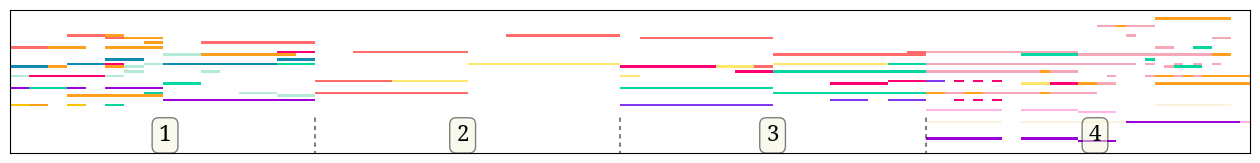

In [8]:
import matplotlib.colors as mcolors


# Cmap
# colors = [
#     "#440154", "#482677", "#3F4788", "#31688E", "#26828E",
#     "#1F9D8A", "#6CCE5A", "#B5DE2B", "#E3E418", "#FDE725",
#     "#FFB14E", "#FA8775", "#EA5F94"
# ]

# colors = [
#     "#264653", "#2A9D8F",  # Deep Teal, Turquoise  
#     "#8AB17D", "#E9C46A",  # Sage Green, Muted Gold  
#     "#F4A261", "#E76F51",  # Warm Coral, Burnt Red  
#     "#6A0572", "#3D348B",  # Dark Purple, Deep Blue  
#     "#22577A", "#38A3A5",  # Ocean Blue, Soft Aqua  
#     "#57CC99", "#9D0208",  # Fresh Green, Burgundy  
#     "#D00000"             # Crimson  
# ]

colors = [
    "#FF6B6B", "#FFE66D",  # Cherry Red, Soft Yellow  
    "#06D6A0", "#118AB2",  # Neon Mint, Aqua Blue  
    "#8338EC", "#FF006E",  # Deep Purple, Raspberry  
    "#FF9F1C", "#FDC500",  # Tangerine, Golden Yellow  
    "#FAF3DD", "#B5EAD7",  # Soft Cream, Pastel Green  
    "#F7A8B8", "#FFB5E8",  # Baby Pink, Bubblegum  
    "#9D02D7"             # Electric Violet  
]

# colors = [
#     "#FF6B6B", "#FFA500",  # Strawberry Red, Candy Orange  
#     "#FFD700", "#00A6FB",  # Neon Yellow, Electric Blue  
#     "#F28500", "#8338EC",  # Deep Tangerine, Vivid Purple  
#     "#F15BB5", "#3A86FF",  # Magenta, Bright Blue  
#     "#06D6A0", "#FF007F",  # Mint Green, Neon Pink  
#     "#118AB2", "#9B5DE5",  # Cool Cyan, Soft Purple  
#     "#39FF14"             # Electric Green  
# ]



cmap = mcolors.ListedColormap(colors)


instr_ordered = ['flute', 'oboe', 'clarinet', 'alto-saxophone', 'bassoon', 'horn', 'trumpet', 'tuba', 'timpani', 'piano', 'strings', 'cello', 'contrabass']

midi_data = Read_midi("midi_examples/mega_pianoroll.mid", 4).read_file()
midi_data = dict((instr, midi_data[instr]) for instr in instr_ordered)


data_nan = {}
for ii, (k, v) in enumerate(midi_data.items()):
    data_nan[k] = v
    data_nan[k] = np.where(data_nan[k] == 0, 0, data_nan[k])
    data_nan[k] = np.where(data_nan[k] > 0, ii+1, data_nan[k])
    print(ii+1, k, end=' | ')
    
per_track_pianoroll = np.maximum.reduce(list(data_nan.values()))
per_track_pianoroll = np.where(per_track_pianoroll == 0, np.nan, per_track_pianoroll)

fig, ax = plt.subplots(figsize=(16, 3))

im = ax.imshow(per_track_pianoroll.T+0.5, cmap=cmap, aspect=0.25, interpolation="none", origin='lower')
# fig.colorbar(im, ticks=range(len(data_nan)))
ax.set_ylim(30, 90)
plt.xticks([], [])
plt.yticks([], [])

plt.axvline(2 * (per_track_pianoroll.T.shape[1]/8) - 1, ymax=0.25, dashes=(1,1,0), c='k', alpha=0.5)
plt.axvline(4 * (per_track_pianoroll.T.shape[1]/8) - 1.5, ymax=0.25, dashes=(1,1,0), c='k', alpha=0.5)
plt.axvline(6 * (per_track_pianoroll.T.shape[1]/8) - 2, ymax=0.25, dashes=(1,1,0), c='k', alpha=0.5)

props = dict(boxstyle='round', facecolor='beige', alpha=0.5)

# place a text box in upper left in axes coords
ax.text(0.12, 0.2, '1', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.36, 0.2, '2', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.61, 0.2, '3', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.87, 0.2, '4', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)

plt.savefig('figures/gen_pianoroll.pdf', bbox_inches='tight')

0.4 0.0 contrabass
0.4 0.15000000000000002 cello
0.4 0.30000000000000004 strings
0.4 0.45000000000000007 piano
0.4 0.6000000000000001 timpani
0.4 0.7500000000000001 tuba
0.4 0.9000000000000001 trumpet
0 0.07000000000000017 horn
0 0.22000000000000008 bassoon
0 0.37 saxophone
0 0.5200000000000001 clarinet
0 0.6700000000000003 oboe
0 0.8200000000000002 flute


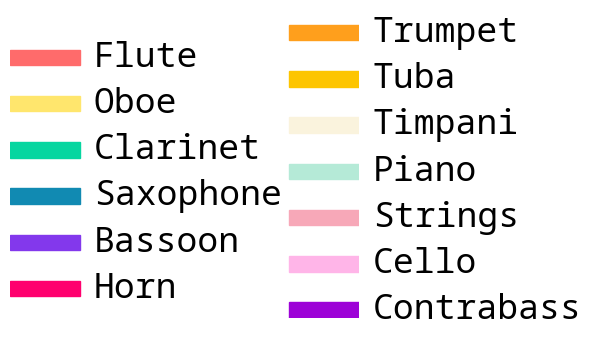

In [70]:
labels = midi_data.keys()
color_to_labels = dict((label, color) for label, color in zip(labels, colors))
# color_to_labels = dict((label, d[label]) for label in reversed(instr_ordered))


# Add color patches with white spacing
patch_height = 0.05  # Height of each patch
patch_width = 0.1  # Height of each patch
spacing = 0.1       # Space between patches


# Create figure and axis
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.set_xlim(0, 0.5)  # Extra space for labels
ax.set_ylim(0, 1)  # Add spacing
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

pad_x = 0.4

for i, (label, color) in enumerate(reversed(color_to_labels.items())):
    if label == 'alto-saxophone': label = 'saxophone'
    y_position = i * (patch_height + spacing)
    if i > 6:
        pad_x = 0
        y_position -= 6 * (patch_height + spacing) + 0.08
    
    print(pad_x, y_position, label)
    rect = patches.Rectangle((pad_x, y_position), patch_width, patch_height, color=color)
    ax.add_patch(rect)
    ax.text(pad_x + patch_width + 0.02, y_position + patch_height / 2, label.capitalize(), va='center', fontsize=25, fontname='Noto Sans Mono')

plt.savefig('figures/gen_legend.pdf', bbox_inches='tight')

0.8 0.0 contrabass
0.8 0.15000000000000002 cello
0.8 0.30000000000000004 strings
0.8 0.45000000000000007 piano
0.42 -0.0050000000000000044 timpani
0.42 0.14500000000000002 tuba
0.42 0.29500000000000004 trumpet
0.42 0.4450000000000002 horn
0 -0.08499999999999996 bassoon
0 0.06499999999999995 saxophone
0 0.21500000000000008 clarinet
0 0.3650000000000003 oboe
0 0.5150000000000002 flute


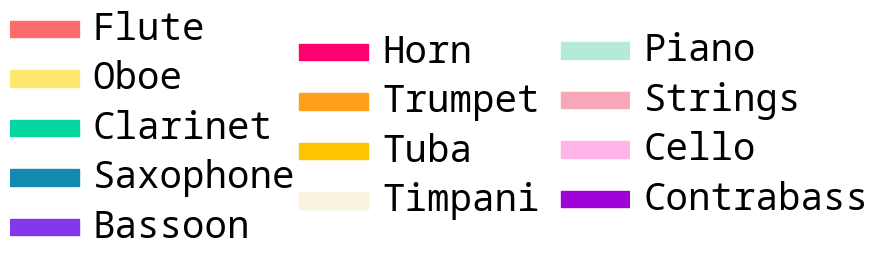

In [74]:
labels = midi_data.keys()
color_to_labels = dict((label, color) for label, color in zip(labels, colors))
# color_to_labels = dict((label, d[label]) for label in reversed(instr_ordered))


# Add color patches with white spacing
patch_height = 0.05  # Height of each patch
patch_width = 0.1  # Height of each patch
spacing = 0.1       # Space between patches


# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_xlim(0, 0.9)  # Extra space for labels
ax.set_ylim(-.1, .6)  # Add spacing
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

pad_x = 0.8

for i, (label, color) in enumerate(reversed(color_to_labels.items())):
    if label == 'alto-saxophone': label = 'saxophone'
    y_position = i * (patch_height + spacing)
    if i > 3:
        pad_x = 0.42
        y_position -= 3.5 * (patch_height + spacing) + 0.08
    if i > 7:
        pad_x = 0
        y_position -= 4 * (patch_height + spacing) + 0.08
    
    print(pad_x, y_position, label)
    rect = patches.Rectangle((pad_x, y_position), patch_width, patch_height, color=color)
    ax.add_patch(rect)
    ax.text(pad_x + patch_width + 0.02, y_position + patch_height / 2, label.capitalize(), va='center', fontsize=27, fontname='Noto Sans Mono')

plt.savefig('figures/gen_legend_small.pdf', bbox_inches='tight')

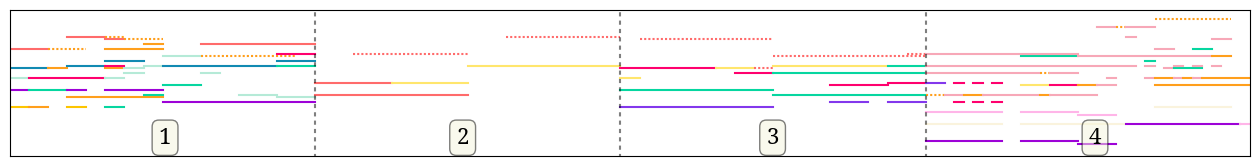

In [10]:
pr = pr_orch_more
melody_pitch_pos = [
    (4, 74), (10, 79), (12, 78), (20, 71),
    (36, 72), (52, 79),
    (66, 78), (78, 66), (80, 71), (94, 72),
    (96, 55), (108, 64), (116, 83), (120, 86)
]

fig, ax = plt.subplots(figsize=(16, 1.9))
df_instr_onsets = make_df_instr_onsets(per_track_pianoroll.T - 1)
for ii, row in df_instr_onsets.iterrows():
    c = cmap(int(row['instr']))
    if (row.min_pos, row.pitch) in melody_pitch_pos:
        linestyle = (0, (1, 1))
    else:
        linestyle = 'solid'
    plt.plot([row.min_pos, row.max_pos], [row.pitch, row.pitch], c=c, linestyle=linestyle)

plt.axvline(2 * (per_track_pianoroll.T.shape[1]/8) - 0.5, ymax=4, dashes=(1,1,0), c='k', alpha=0.5)
plt.axvline(4 * (per_track_pianoroll.T.shape[1]/8) - 1, ymax=4, dashes=(1,1,0), c='k', alpha=0.5)
plt.axvline(6 * (per_track_pianoroll.T.shape[1]/8) - 1.5, ymax=4, dashes=(1,1,0), c='k', alpha=0.5)

props = dict(boxstyle='round', facecolor='beige', alpha=0.5)

# place a text box in upper left in axes coords
ax.text(0.12, 0.2, '1', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.36, 0.2, '2', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.61, 0.2, '3', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)
ax.text(0.87, 0.2, '4', transform=ax.transAxes, fontsize=16, verticalalignment='top', bbox=props, fontname=serif_fontname)

plt.xlim([0, 130])
plt.ylim([30, 90])
plt.xticks([], [])
plt.yticks([], [])
plt.savefig('figures/gen_pianoroll_melody.pdf', bbox_inches='tight')
